In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
import cmcrameri as cm
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors

import statsmodels.api as sm
import pymannkendall as mk
from global_land_mask import globe

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/observations_reanalysis_data/'
start_year = 2003
end_year = 2025
ref_timeslice=slice(1970,2000)

Arctic_limit = 60
land_longitudes = slice(0,300) # Exclude Greenland

spring_summer_months = [3, 4, 5, 6, 7, 8]
spring_summer_label = 'MAMJJA'
summer_months = [6, 7, 8]

## Plotting

<>:21: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:21: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3653180/3220446772.py:21: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  units = ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$', '% decade$^{-1}$', '$^{\circ}$C decade$^{-1}$']


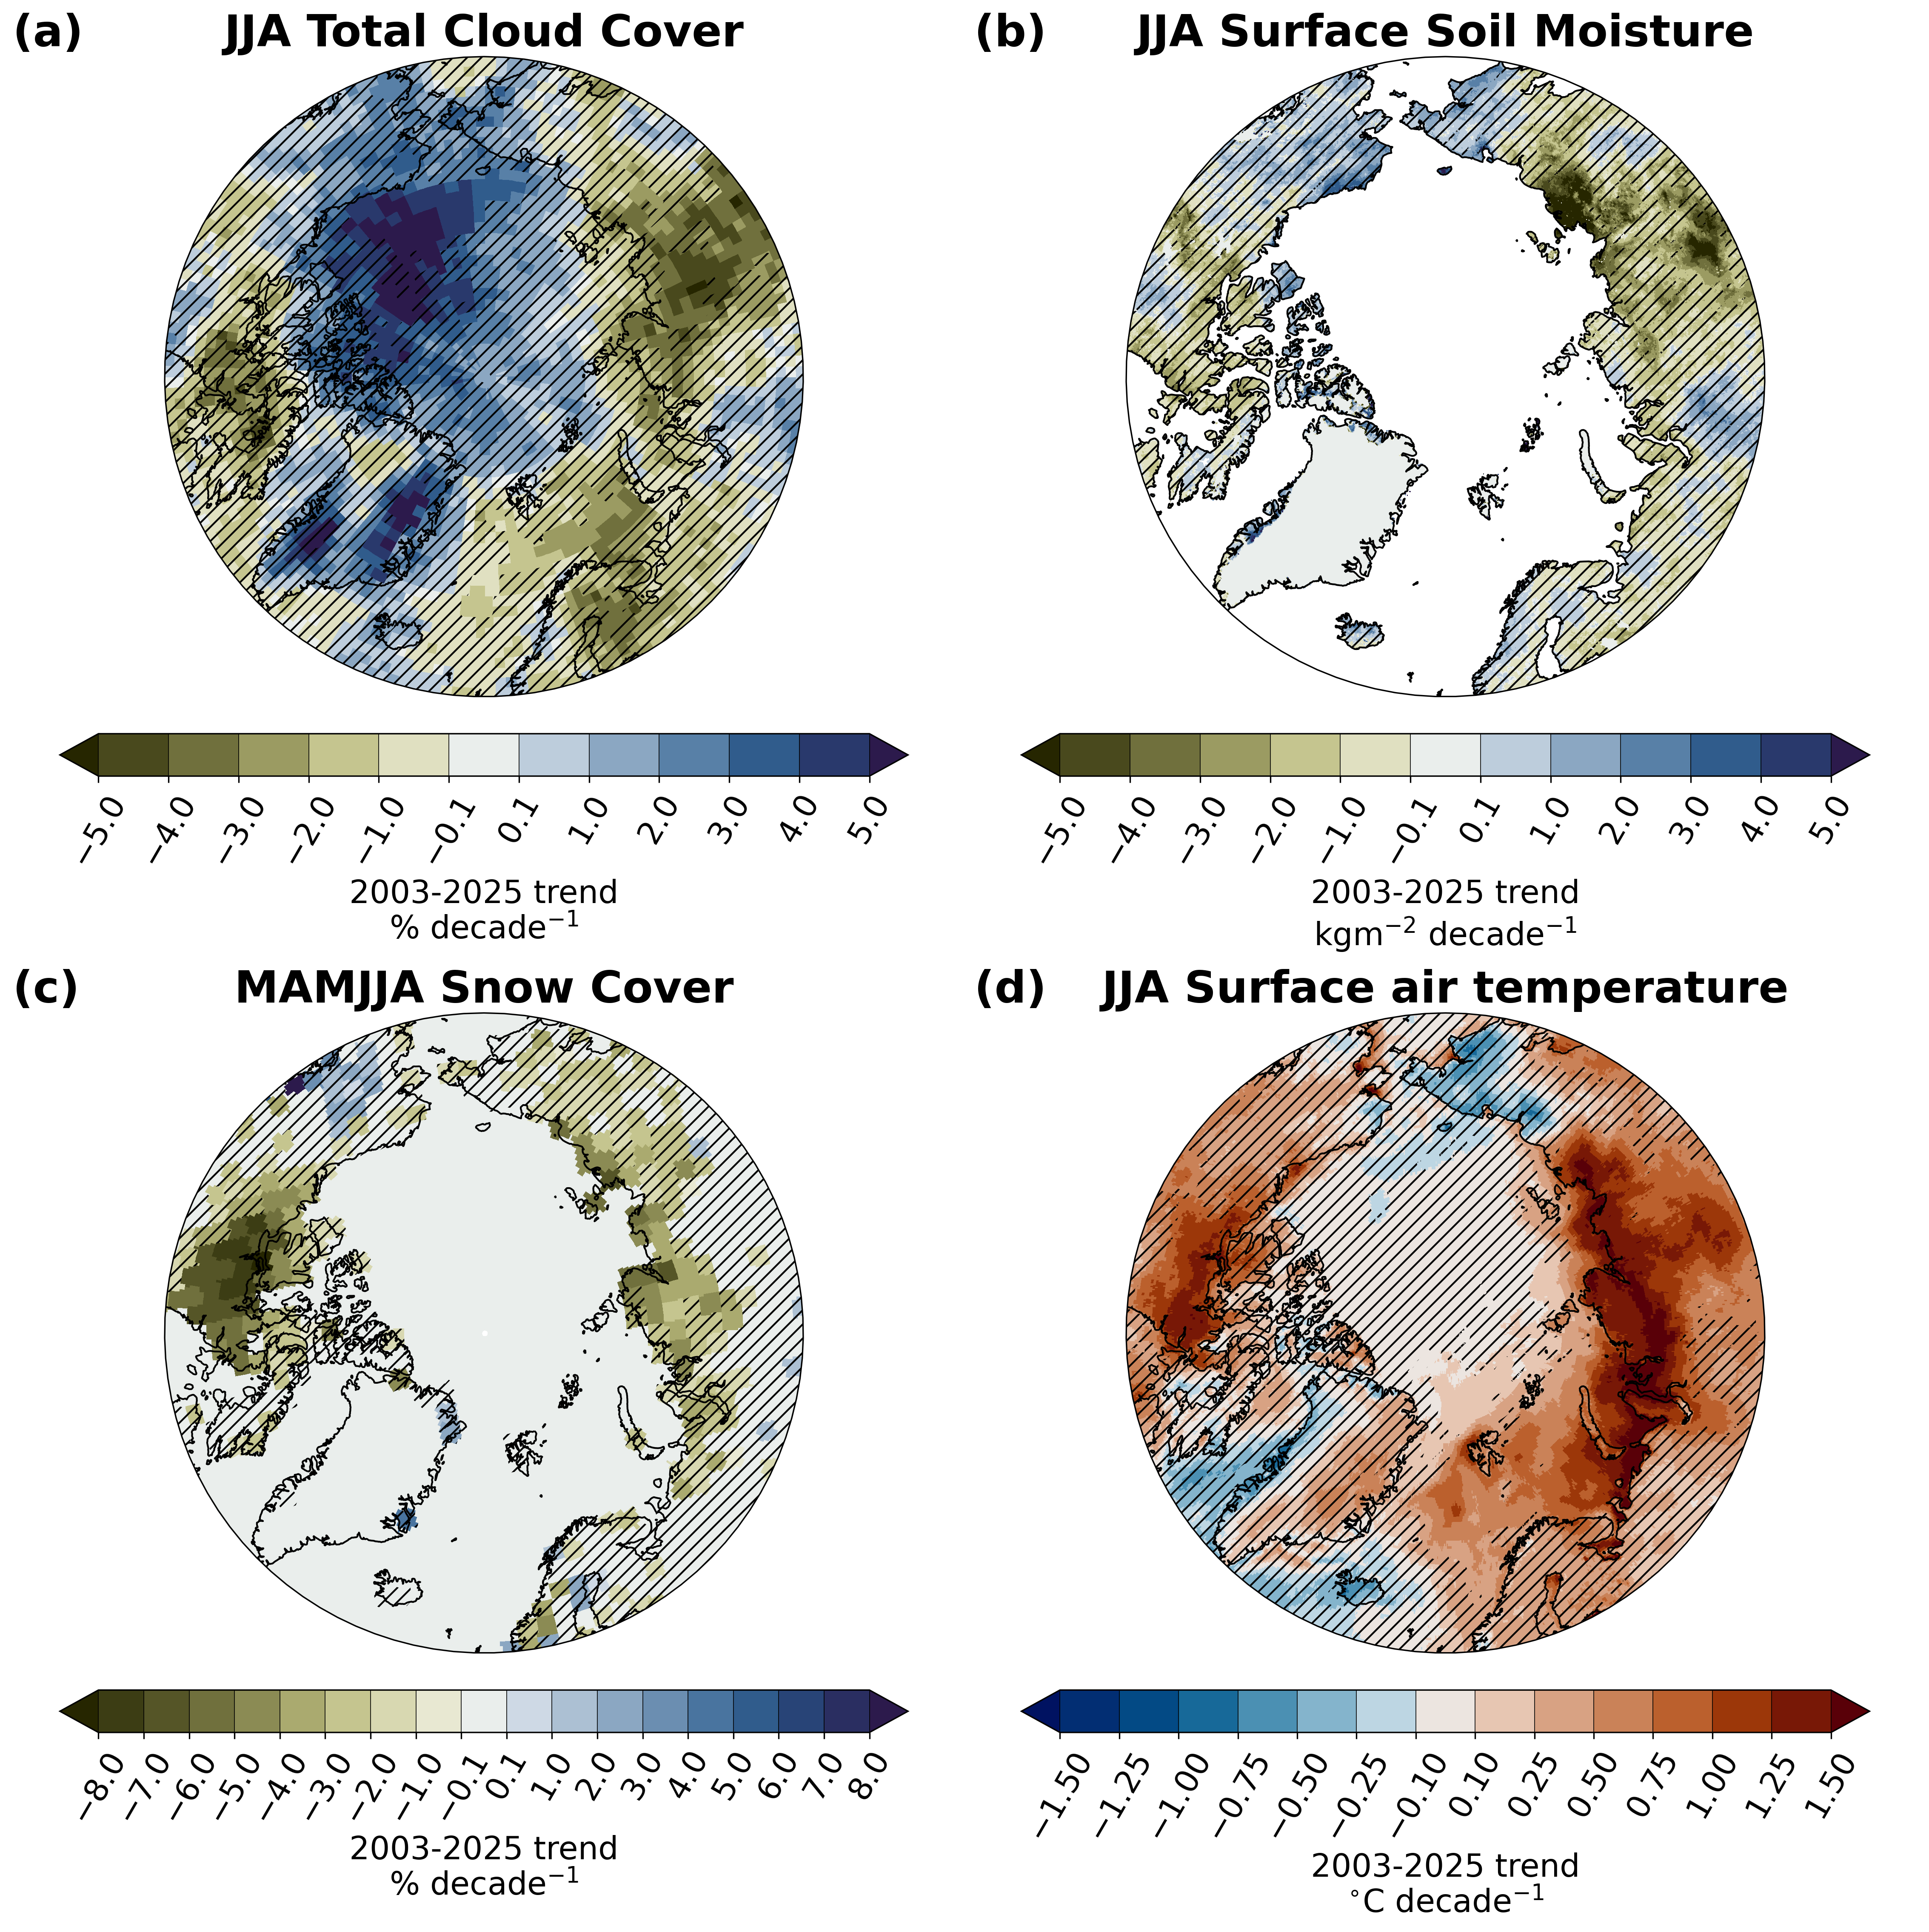

In [ ]:
labels = [['(a)','(b)'], ['(c)', '(d)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 15),dpi=300, 
                              constrained_layout=True)

# Remove axis from map plots
for label in ['(a)', '(b)', '(c)', '(d)']:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.Orthographic(0, 90))
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Orthographic(0, 90))
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Orthographic(0, 90))

titles = ['JJA Total Cloud Cover', 'JJA Surface Soil Moisture', 'MAMJJA Snow Cover', 'JJA Surface air temperature']
units = ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$', '% decade$^{-1}$', '$^{\circ}$C decade$^{-1}$']
files = ['cloud_cover/CERES_trends_JJA_2003_2025.nc', 'soil_moisture/SM_ERA5_trends_JJA_2003_2025.nc',
         'snow_cover/sce_trends_MAMJJA_2003_2025.nc', 'temperature/temp_trends_JJA_2003_2025.nc']
limits = [5, 5, 8, 1.5]
increments = [1, 1, 1, 0.25]
cmaps = [cm.cm.broc_r, cm.cm.broc_r, cm.cm.broc_r, cm.cm.vik]


# Row |: spatial trends
for ax, title, unit, file, limit, inc, cmap in zip([ax1, ax2, ax3, ax4], titles, units, files, limits, increments, cmaps):

    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend']*10 # multiply by 10 to get trend per decade 
    
    # Set colormap spacing
    uneven_levels = list(np.flip(-np.arange(inc, limit+inc, inc)))+[-0.1,0.1]+list(np.arange(inc, limit+inc, inc))
    colors = cmap(np.linspace(0, 1, len(uneven_levels)+1))
    cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap=cmap, norm=norm,
                                        add_colorbar=False)
    hatch_density=3
    hatch_style='/'
    insignificant_data = functions.xr_add_cyclic_point(ds['p_value'] > significance_level)
    hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    
    ax.set_title(title, fontsize=25, fontweight='bold')
    ax.coastlines()

    # Colorbar
    cb = fig.colorbar(map, ax=ax, location='bottom', ticks=uneven_levels, drawedges=True,extend='both',shrink=0.9)
    cb.set_label(label='2003-2025 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18, rotation=60)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=25,fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA5.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA5.pdf')

NameError: name 'xr_add_cyclic_point' is not defined

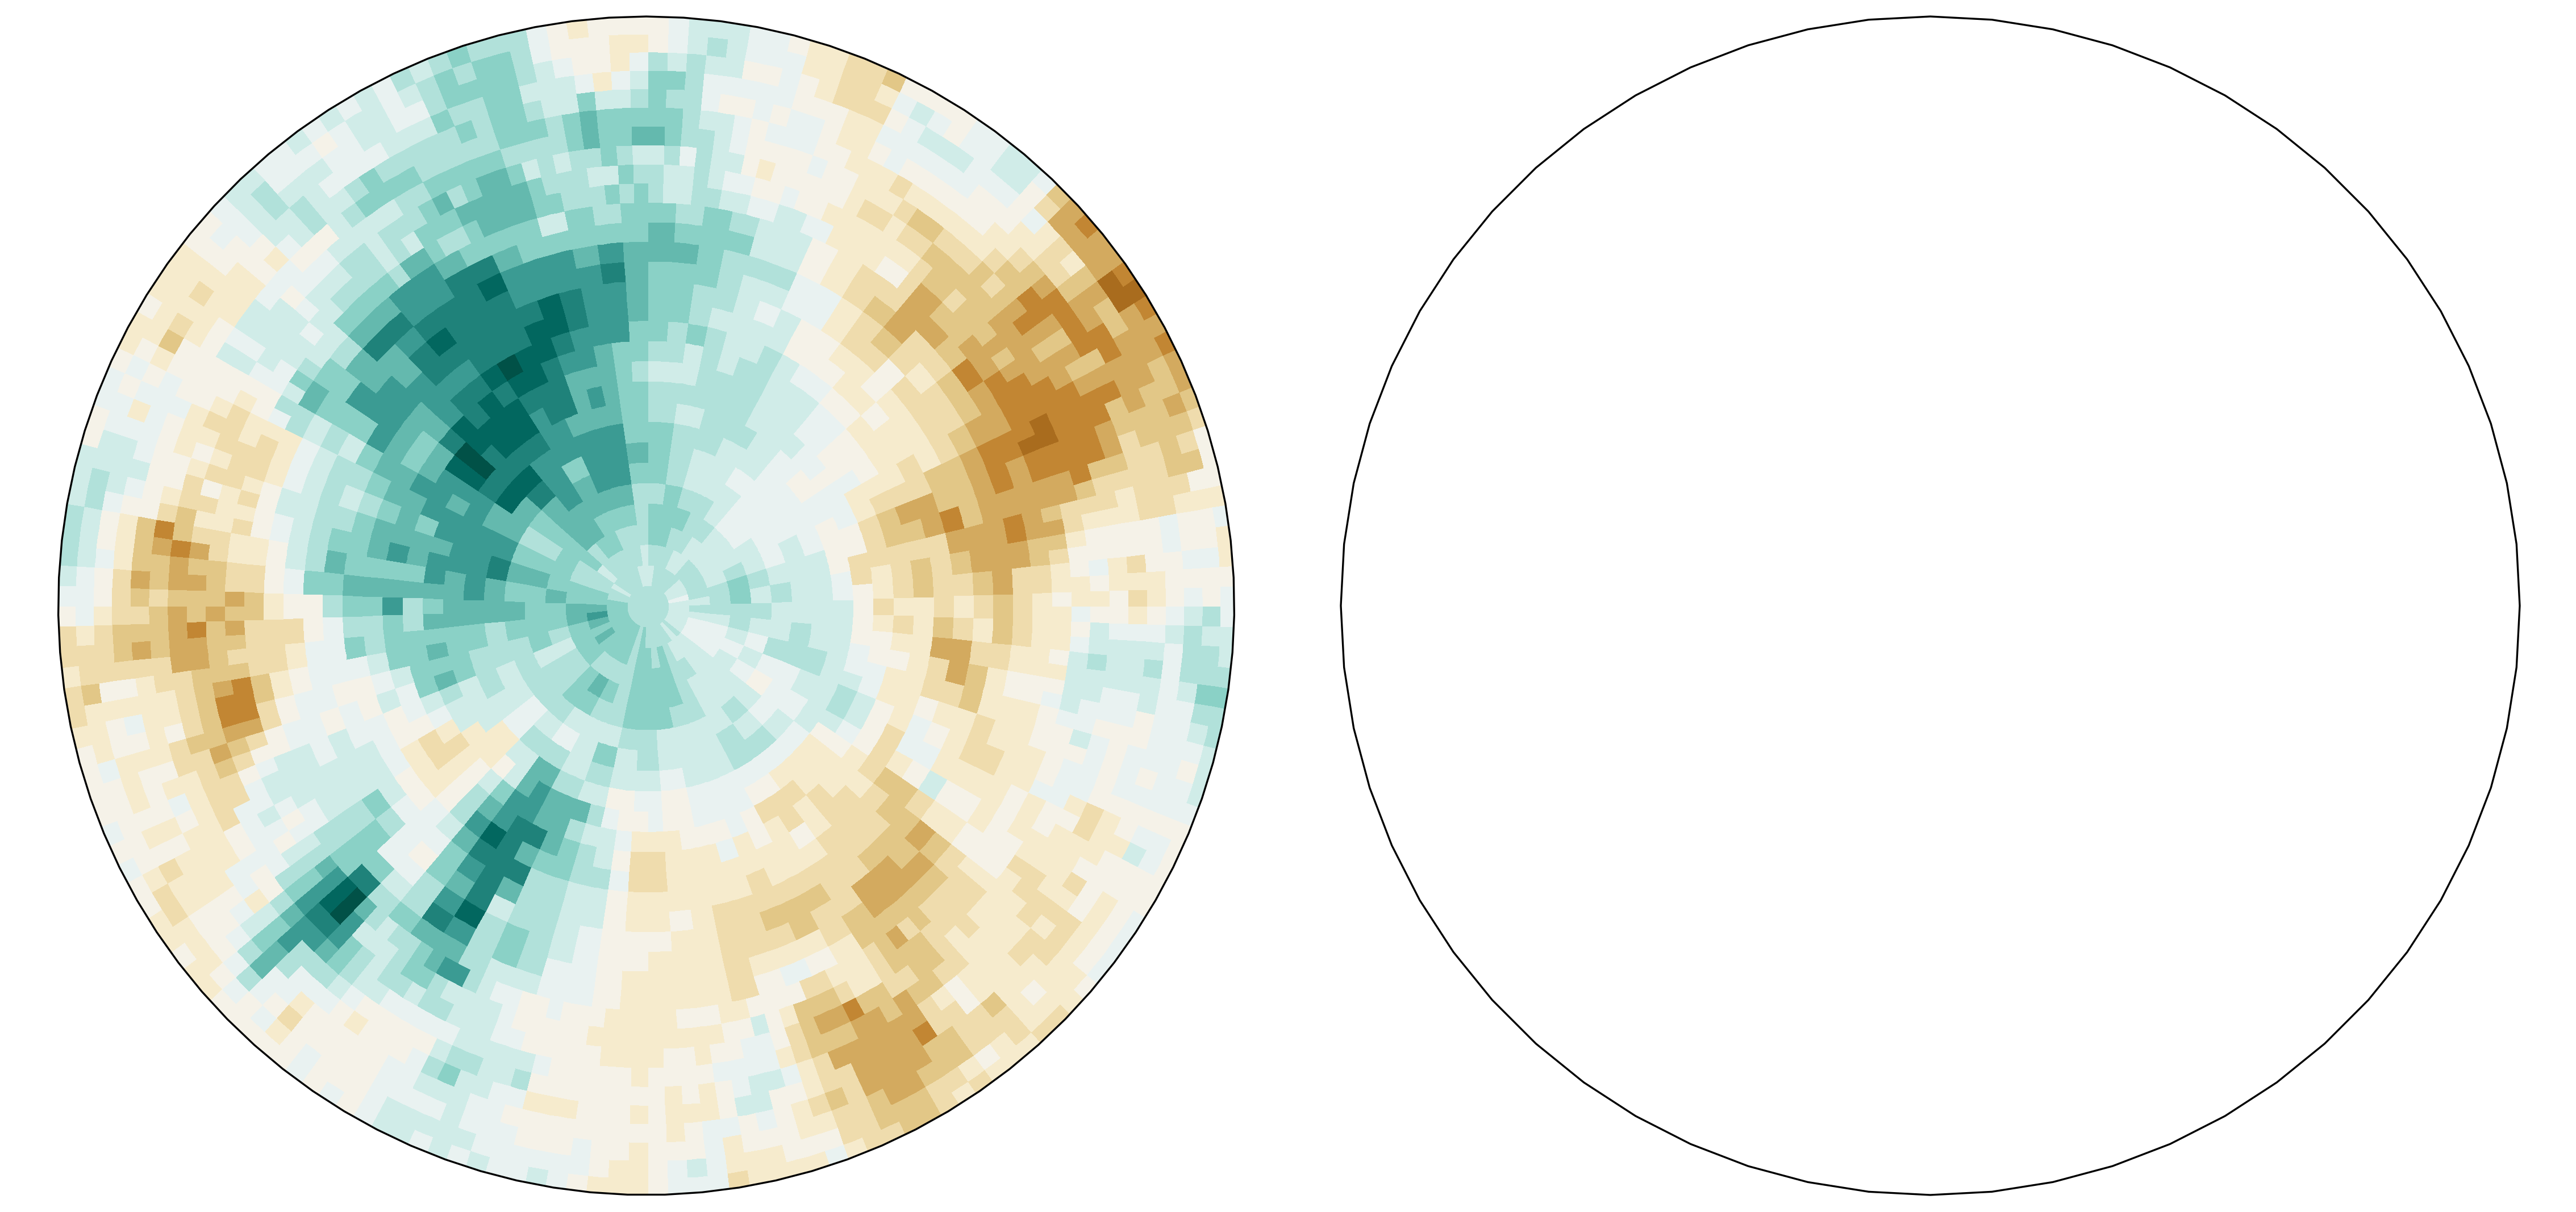

In [ ]:
labels = [['(a)','(a)','(b)','(b)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 7),dpi=300, 
                              constrained_layout=True)

# Remove axis from map plots
for label in ['(a)', '(b)']:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 90))


# Row |: spatial trends
for ax, title, unit, file, limit in zip([ax1, ax2], 
                                  ['CERES EBAF (MODIS)\nTotal Cloud Cover', 'ERA5-Land\nTop 10 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['cloud_cover/CERES_trends_summer_2003_2025.nc', 'soil_moisture/SM_ERA5_trends_summer_2003_2025.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    if ax == ax1:
        data = ds['trends']*10 # multiply by 10 to get trend per decade
    elif ax == ax2:
        data = ds['trend'].T*10 # multiply by 10 to get trend per decade 
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch_density=3
    hatch_style='/'
    if ax == ax1:
        insignificant_data = functions.xr_add_cyclic_point(ds['p_values'] > significance_level)
        hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    

    elif ax == ax2:
        insignificant_data = functions.xr_add_cyclic_point(ds['p_value'].T > significance_level)
        hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    


    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    #hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2003-2025 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
#fig.tight_layout()

#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.png')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.pdf')

In [ ]:
#CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc')
CERES = CERES.sel(time=slice('2003-01-01','2025-12-1'))

# Select season
timeslice_trend=slice(2003,2025)
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create weighted linear regression
x = CERES_season_annual.year.values
x = x
y = CERES_season_annual.values
weights = np.ones(len(x))

# Fit weighted least squares regression model
X = sm.add_constant(x)
model = sm.WLS(y, X, weights=weights)
CERES_fit = model.fit()
CERES_slope = CERES_fit.params[1]
CERES_intercept = CERES_fit.params[0]
CERES_p_value = CERES_fit.pvalues[1]
CERES_std_err = CERES_fit.bse[1]
print(CERES_fit.summary())

for season in ["JJA"]:
    ds_season = CERES['cldarea_total_daynight_mon'].sel(time=CERES.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')
    
    x = ds_annual.year.values
    weights = np.ones(len(x))
    # Add a smaller weight to first point, as it does not include June
    weights[0] = 2/3
    X = sm.add_constant(x)

    trends = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    p_values = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    for ilon in range(len(CERES.lon)):
        for ilat in range(len(CERES.lat)):
            y = ds_annual.isel(lon=ilon, lat=ilat).values
            model = sm.WLS(y, X, weights=weights)
            CERES_fit = model.fit()

            trends[ilon, ilat] = CERES_fit.params[1]
            p_values[ilon, ilat] = CERES_fit.pvalues[1]
    
    ds_annual['trend'] = ({'lon':CERES.lon, 'lat':CERES.lat}, trends)
    ds_annual['p_value'] = ({'lon':CERES.lon, 'lat':CERES.lat}, p_values)

    ds_annual.to_netcdf(rpath+"CERES_trends_"+season+"_2002_2025.nc")

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.173
Model:                            WLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     4.617
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0429
Time:                        17:39:46   Log-Likelihood:                -40.430
No. Observations:                  24   AIC:                             84.86
Df Residuals:                      22   BIC:                             87.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        244.0488     80.884      3.017      0.0

In [6]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')

datadir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'
landfrac = xr.open_dataarray(datadir+'LANDFRAC_piClim.nc')
landmask = landfrac.isel(time=0)
oceanmask = 1-landmask

# Interpolate to 
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
landmask_CERES = landmask_CERES.where(landmask_CERES>=0)
landmask_CERES = landmask_CERES.fillna(0)

oceanmask_CERES = 1-landmask_CERES

In [65]:
SM_ERA5

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 168, lat: 301, lon: 3600)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1970-06-01 1970-07-01 ... 2025-08-01
    expver     (time) <U4 3kB ...
  * lat        (lat) float64 2kB 60.0 60.1 60.2 60.3 ... 89.7 89.8 89.9 90.0
  * lon        (lon) float64 29kB 0.1 0.2 0.3 0.4 ... 359.7 359.8 359.9 360.0
    number     int64 8B ...
Data variables:
    swvl1      (time, lat, lon) float32 728MB ...
    swvl2      (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
    swvl_20cm  (time, lat, lon) float32 728MB ...
    swvl_10cm  (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-30T14:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [66]:
SM_ERA5

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 168, lat: 301, lon: 3600)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1970-06-01 1970-07-01 ... 2025-08-01
    expver     (time) <U4 3kB ...
  * lat        (lat) float64 2kB 60.0 60.1 60.2 60.3 ... 89.7 89.8 89.9 90.0
  * lon        (lon) float64 29kB 0.1 0.2 0.3 0.4 ... 359.7 359.8 359.9 360.0
    number     int64 8B ...
Data variables:
    swvl1      (time, lat, lon) float32 728MB ...
    swvl2      (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
    swvl_20cm  (time, lat, lon) float32 728MB ...
    swvl_10cm  (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-30T14:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [72]:
# Select season
timeslice_trend=slice('2002-01-01','2025-12-01')
SM_ERA5_slice = SM_ERA5.sel(time=timeslice_trend)

# Annual season mean
ds_season = SM_ERA5_slice['swvl_10cm'].sel(time=SM_ERA5_slice.time.dt.season=='JJA')
ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

x = ds_annual.year.values
X = sm.add_constant(x)

trends = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
p_values = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
for ilon in range(len(SM_ERA5_slice.lon)):
    for ilat in range(len(SM_ERA5_slice.lat)):
        y = ds_annual.isel(lon=ilon, lat=ilat).values*100
        model = sm.WLS(y, X)
        fit = model.fit()

        trends[ilon, ilat] = fit.params[1]
        p_values[ilon, ilat] = fit.pvalues[1]

ds_annual['trend'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, trends)
ds_annual['p_value'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, p_values)

ds_annual.to_netcdf(rpath+"SM_ERA5_trends_"+season+"_2002_2025.nc")

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual['swvl_10cm']*100 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2025.nc")

In [70]:
var = 'swvl1'
ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_20cm_trends_"+season+".nc")


In [75]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(2002,2024)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(2002,2024)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2024.nc")


In [25]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
var='swvl1'

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(1970,2016)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(1970,2016)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_1970_2016.nc")


In [4]:
season="JJA"
rpath = "/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
ds_annual = xr.open_dataset(rpath+"SM_ERA5_trends_"+season+".nc")
ds_annual = ds_annual.reindex(latitude=list(reversed(ds_annual.latitude)))

In [36]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'
ds_SM_WM = xr.open_dataset(filepath)